# Tag List effect on ratings : Sheryl Boateng

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

## Data Statistics

In [165]:
makeup_data = pd.read_csv("/Users/sherylboateng/Desktop/TEPP_Data_Project/data/processed/clean_makeup.csv")

makeup_data.info()
makeup_data.describe().round()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    int64  
 1   brand         919 non-null    object 
 2   name          931 non-null    object 
 3   category      507 non-null    object 
 4   product_type  931 non-null    object 
 5   price         917 non-null    float64
 6   currency      368 non-null    object 
 7   tag_list      931 non-null    object 
 8   rating        340 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 65.6+ KB


,id,price,rating
count,931.0,917.0,340.0
mean,531.0,17.0,4.0
std,311.0,11.0,1.0
min,1.0,0.0,2.0
25%,263.0,9.0,4.0
50%,518.0,14.0,4.0
75%,814.0,22.0,5.0
max,1048.0,77.0,5.0


## Data Cleaning

I am focusing on the products that have ratings and comparing the tag_list so the first task is to remove the products with a null or an empty string as a rating; these products will hinder my analysis.

In [166]:
no_nan_values = makeup_data[makeup_data['rating'].notna() & (makeup_data['tag_list'] != '[]')]
no_nan_values['tag_list'].value_counts()

tag_list
['Gluten Free']                                                                                         29
['Vegan']                                                                                               23
['Canadian', 'Natural']                                                                                 18
['Gluten Free', 'Natural']                                                                              11
['Natural']                                                                                             10
['Vegan', 'Natural']                                                                                     7
['Vegan', 'Gluten Free', 'Natural']                                                                      6
['Canadian']                                                                                             4
['Natural', 'Gluten Free']                                                                               4
['Canadian', 'Gluten Free'] 

### For Loop To sort and remove duplicated tag list combination

1. I went into dataFrame and targeted the 'taglist' row, so that I can loop through each one
2. It was a string so I converted into a list
3. Then I used the sorted function through sort through each 'tag_list'
4. Then I converted the list into a tuple because when I use groupby the values need to be keys
5. Then I updated tag_list in the DataFrame in order to be able to pull descriptive analysis from it

In [167]:
for index, row in no_nan_values.iterrows():
        str_list = row['tag_list']
        new_list = ast.literal_eval(str_list)
        sorted_list = sorted(new_list)
        tupled_list = tuple(sorted_list)
        no_nan_values.at[index, 'tag_list'] = tupled_list
       

### New Tag list without Duplicates

In [168]:
no_nan_values['tag_list'].value_counts().reset_index()

,tag_list,count
0,"(Gluten Free,)",29
1,"(Vegan,)",23
2,"(Canadian, Natural)",19
3,"(Gluten Free, Natural)",15
4,"(Natural,)",10
5,"(Natural, Vegan)",9
6,"(Gluten Free, Natural, Vegan)",6
7,"(Canadian,)",4
8,"(Canadian, Gluten Free, Natural, Non-GMO, Vegan)",3
9,"(Canadian, Natural, Vegan)",3


## Data Exploration

### Average rating for each unique combination of tag_list

In [169]:
no_nan_values.groupby('tag_list')['rating'].mean().round(2).reset_index()


,tag_list,rating
0,"(Canadian,)",3.90
1,"(Canadian, Dairy Free, Fair Trade, Gluten Free...",2.50
2,"(Canadian, Gluten Free)",4.17
3,"(Canadian, Gluten Free, Natural)",4.60
4,"(Canadian, Gluten Free, Natural, Non-GMO, Pean...",4.30
5,"(Canadian, Gluten Free, Natural, Non-GMO, Vegan)",4.57
6,"(Canadian, Gluten Free, Natural, Organic)",4.80
7,"(Canadian, Gluten Free, Natural, Organic, Vegan)",3.30
8,"(Canadian, Natural)",4.17
9,"(Canadian, Natural, Vegan)",3.43


In [170]:

no_nan_values.groupby('tag_list')['rating'].max().reset_index()


,tag_list,rating
0,"(Canadian,)",5.0
1,"(Canadian, Dairy Free, Fair Trade, Gluten Free...",3.0
2,"(Canadian, Gluten Free)",5.0
3,"(Canadian, Gluten Free, Natural)",4.6
4,"(Canadian, Gluten Free, Natural, Non-GMO, Pean...",4.3
5,"(Canadian, Gluten Free, Natural, Non-GMO, Vegan)",4.8
6,"(Canadian, Gluten Free, Natural, Organic)",4.8
7,"(Canadian, Gluten Free, Natural, Organic, Vegan)",3.3
8,"(Canadian, Natural)",5.0
9,"(Canadian, Natural, Vegan)",3.5


In [171]:
no_nan_values.groupby('tag_list')['rating'].min().reset_index().sort_values(by='rating')

,tag_list,rating
1,"(Canadian, Dairy Free, Fair Trade, Gluten Free...",2.0
8,"(Canadian, Natural)",2.3
10,"(Gluten Free,)",2.5
11,"(Gluten Free, Natural)",2.5
0,"(Canadian,)",2.6
13,"(Natural,)",3.0
2,"(Canadian, Gluten Free)",3.0
15,"(Natural, Vegan)",3.0
7,"(Canadian, Gluten Free, Natural, Organic, Vegan)",3.3
9,"(Canadian, Natural, Vegan)",3.4


# Data Visualizations

Text(0.5, 1.0, 'Tag List vs Ratings Count')

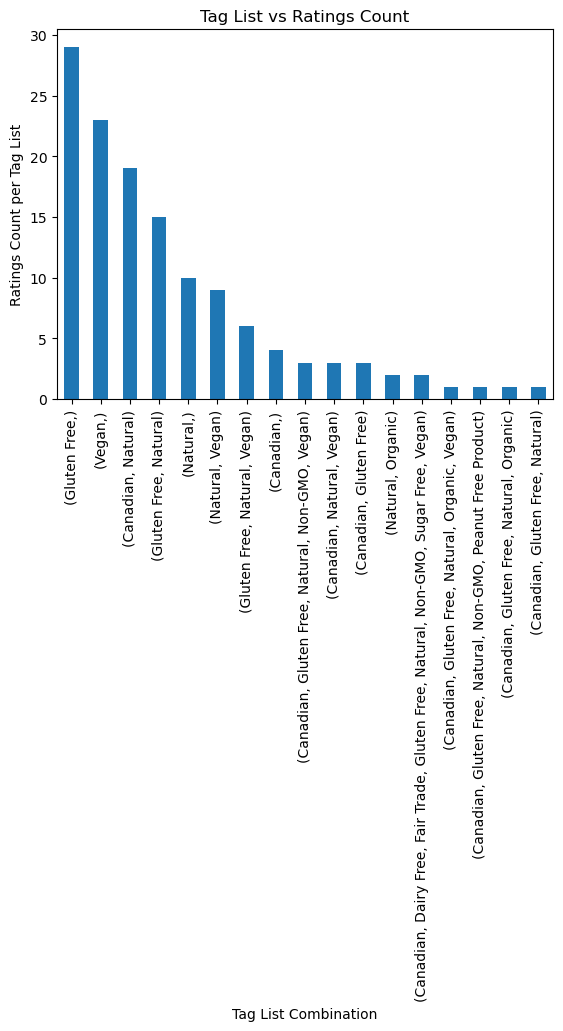

In [172]:
y = no_nan_values['tag_list'].value_counts()
y.plot(kind= 'bar')
plt.xlabel('Tag List Combination')
plt.ylabel('Ratings Count per Tag List')
plt.title('Tag List vs Ratings Count')

In [ ]:
no_nan_values['more_than_two'] = no_nan_values['tag_list'].apply(len)

/var/folders/39/d29jcb4j6r794j7wkqsq4_mr0000gn/T/ipykernel_9339/2279467290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_nan_values['more_than_two'] = no_nan_values['tag_list'].apply(len)


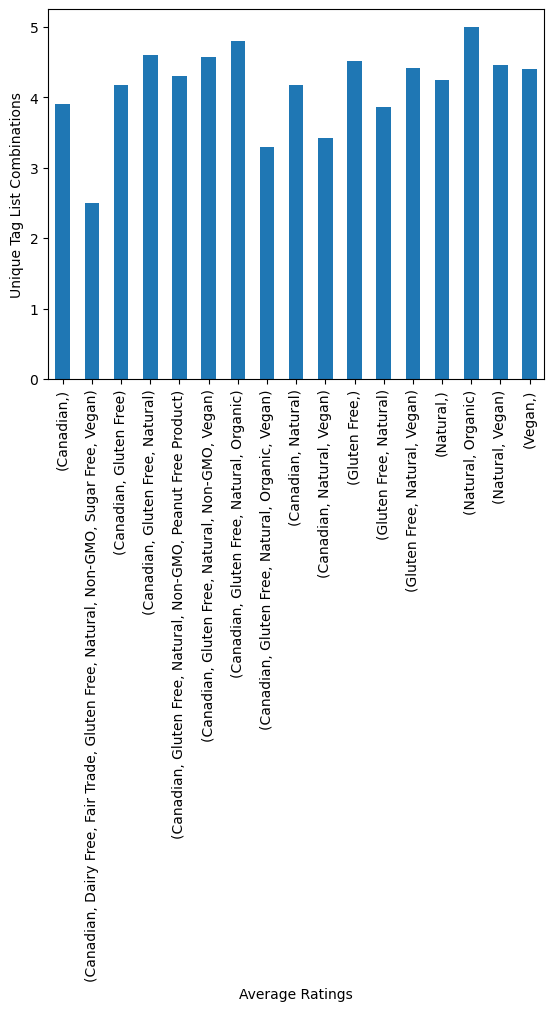

In [174]:

y = no_nan_values.groupby('tag_list')['rating'].mean().round(2)
y.plot(kind= 'bar')
plt.xlabel('Average Ratings')
plt.ylabel('Unique Tag List Combinations')
plt.show()